## Importing libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set(style="whitegrid")

# Data Understanding and Loading data

In [4]:
df = pd.read_csv('ev_vs_petrol_dataset_v3.csv')


# shape of dataset
df.shape
# column names
df.columns

# EV ratio
df['ev_to_total_ratio'] = df['ev_sales'] / df['total_vehicle_sales']

# normalizing data
df['log_gdp'] = np.log(df['gdp_per_capita'])

df.head()

,country,region,year,vehicle_segment,powertrain_type,ev_sales,petrol_car_sales,diesel_car_sales,total_vehicle_sales,ev_market_share,...,avg_ev_range_km,fuel_price_usd_per_liter,electricity_price_usd_per_kwh,gdp_per_capita,urban_population_percent,co2_emissions_transport_mt,ev_subsidy_usd,emission_regulation_score,ev_growth_rate_yoy,is_ev_dominant
0,Australia,Oceania,2010,commercial,ICE,5,92877,61921,154803,0.00,...,124,1.09,0.149,51977,88.8,88.7,0,30.4,0.00,0
1,Australia,Oceania,2010,mass_market,ICE,57,535933,73089,609079,0.01,...,124,1.09,0.149,51977,88.8,88.7,0,30.4,0.00,0
2,Australia,Oceania,2010,premium,ICE,37,235282,20462,255781,0.01,...,124,1.09,0.149,51977,88.8,88.7,0,30.4,0.00,0
3,Australia,Oceania,2011,commercial,ICE,11,98092,65395,163498,0.01,...,133,1.09,0.163,52807,88.9,88.3,0,30.8,120.00,0
4,Australia,Oceania,2011,mass_market,ICE,129,569679,77684,647492,0.02,...,133,1.09,0.163,52807,88.9,88.3,0,30.8,126.32,0


# Data Cleaning

In [ ]:
# remove duplicates
df.drop_duplicates(inplace=True)

# fill missing values
df.ffill(inplace=True)

In [7]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   country                        1200 non-null   object 
 1   region                         1200 non-null   object 
 2   year                           1200 non-null   int64  
 3   vehicle_segment                1200 non-null   object 
 4   powertrain_type                1200 non-null   object 
 5   ev_sales                       1200 non-null   int64  
 6   petrol_car_sales               1200 non-null   int64  
 7   diesel_car_sales               1200 non-null   int64  
 8   total_vehicle_sales            1200 non-null   int64  
 9   ev_market_share                1200 non-null   float64
 10  charging_stations              1200 non-null   int64  
 11  fast_chargers_share            1200 non-null   float64
 12  avg_ev_range_km                1200 non-null   i

,0
country,0
region,0
year,0
vehicle_segment,0
powertrain_type,0
ev_sales,0
petrol_car_sales,0
diesel_car_sales,0
total_vehicle_sales,0
ev_market_share,0


# EV Sales Over Time

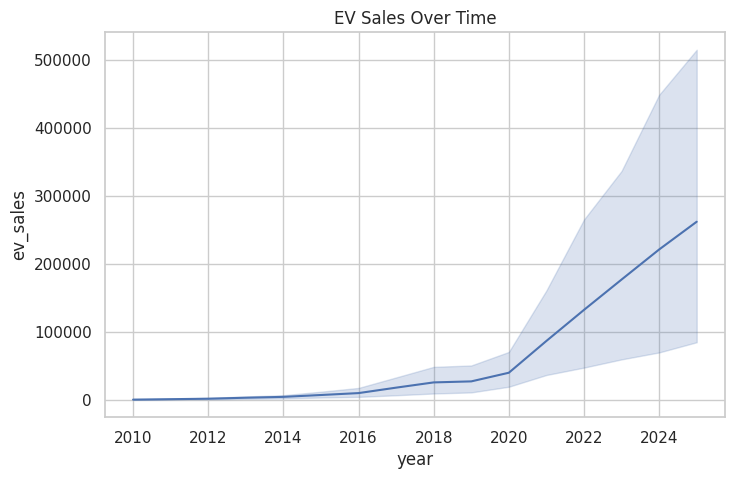

In [ ]:
plt.figure(figsize=(8,5))
sns.lineplot(data=df, x='year', y='ev_sales')
plt.title("EV Sales Over Time")
plt.show()

# EV Market Share Distribution

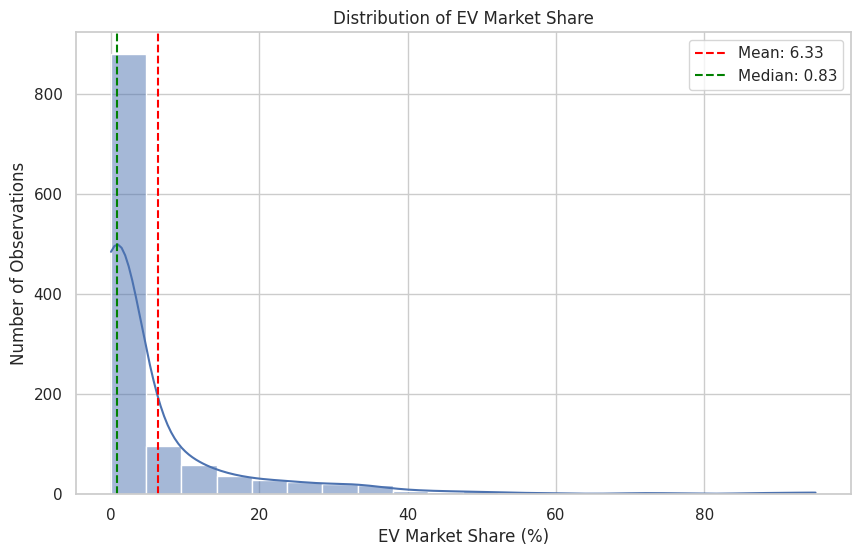

In [6]:
mean_val = df['ev_market_share'].mean()
median_val = df['ev_market_share'].median()

plt.figure(figsize=(10,6))
sns.histplot(df['ev_market_share'], bins=20, kde=True)

plt.axvline(mean_val, color='red', linestyle='--', label=f"Mean: {mean_val:.2f}")
plt.axvline(median_val, color='green', linestyle='--', label=f"Median: {median_val:.2f}")

plt.xlabel("EV Market Share (%)")
plt.ylabel("Number of Observations")
plt.title("Distribution of EV Market Share")

plt.legend()
plt.show()

# Charging Stations vs EV Share

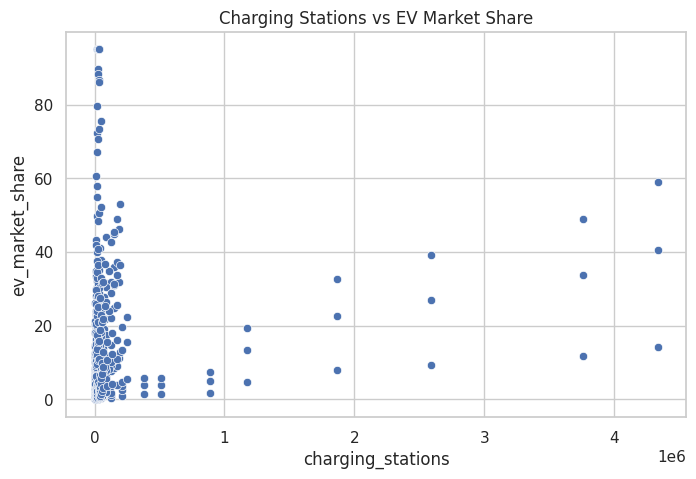

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='charging_stations', y='ev_market_share', data=df)
plt.title("Charging Stations vs EV Market Share")
plt.show()

# Correlation Matrix

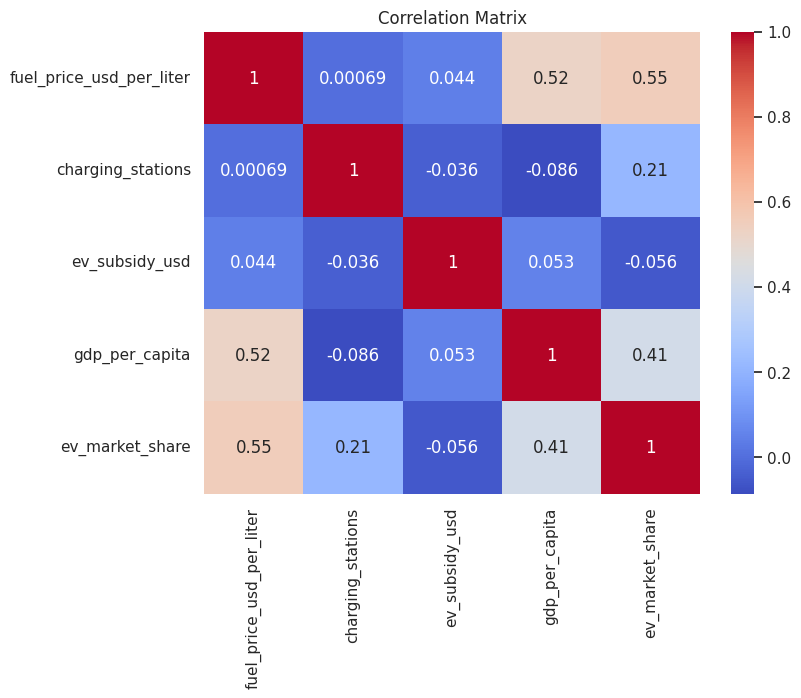

In [ ]:
corr_matrix = df[['fuel_price_usd_per_liter',
                  'charging_stations',
                  'ev_subsidy_usd',
                  'gdp_per_capita',
                  'ev_market_share']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Regression

In [15]:
from sklearn.linear_model import LinearRegression

X = df[['fuel_price_usd_per_liter',
        'charging_stations',
        'ev_subsidy_usd',
        'gdp_per_capita']]

y = df['ev_market_share']

model = LinearRegression()
model.fit(X, y)

# coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Impact': model.coef_
})

coefficients

,Feature,Impact
0,fuel_price_usd_per_liter,16.502969
1,charging_stations,0.000009
2,ev_subsidy_usd,-0.000417
3,gdp_per_capita,0.000110


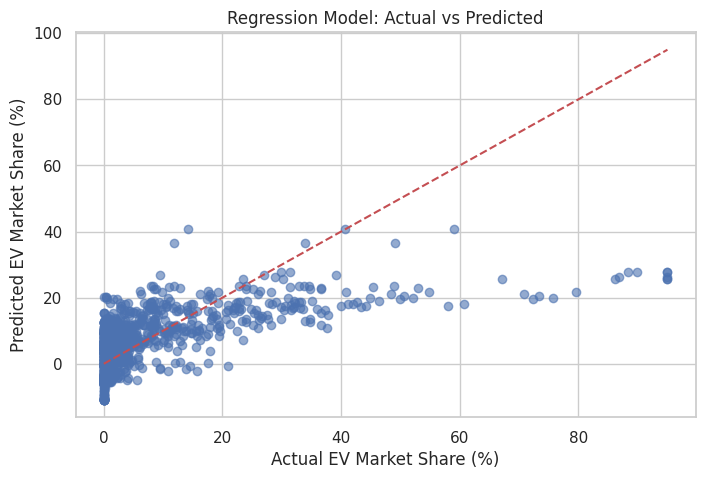

In [16]:
from sklearn.metrics import r2_score

# predictions
y_pred = model.predict(X)

plt.figure(figsize=(8,5))
plt.scatter(y, y_pred, alpha=0.6)

plt.xlabel("Actual EV Market Share (%)")
plt.ylabel("Predicted EV Market Share (%)")
plt.title("Regression Model: Actual vs Predicted")

# reference line
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')

plt.show()

# H1: Fuel Price Effect

“Higher fuel prices lead to higher EV market share.”

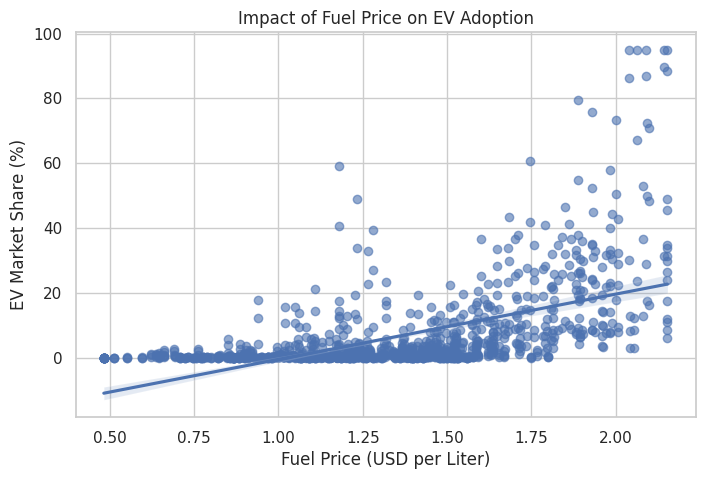

In [9]:
plt.figure(figsize=(8,5))

sns.regplot(
    x='fuel_price_usd_per_liter',
    y='ev_market_share',
    data=df,
    scatter_kws={'alpha':0.6}
)

plt.xlabel("Fuel Price (USD per Liter)")
plt.ylabel("EV Market Share (%)")
plt.title("Impact of Fuel Price on EV Adoption")

plt.show()

# H2: Charging Infrastructure Effect

“More charging stations lead to higher EV market share.”

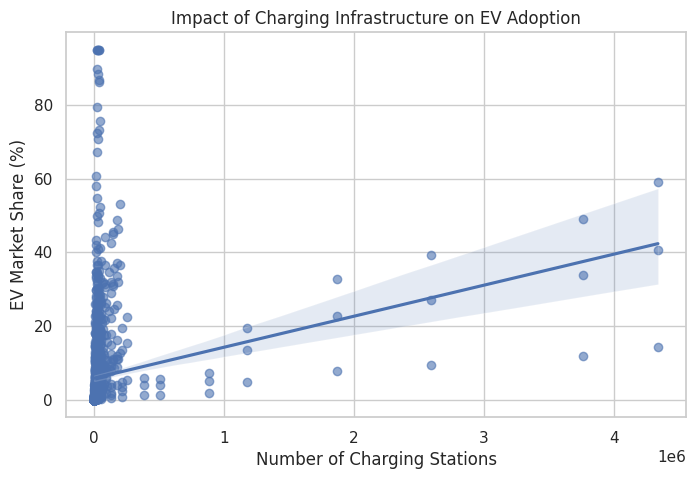

In [10]:
plt.figure(figsize=(8,5))

sns.regplot(
    x='charging_stations',
    y='ev_market_share',
    data=df,
    scatter_kws={'alpha':0.6}
)

plt.xlabel("Number of Charging Stations")
plt.ylabel("EV Market Share (%)")
plt.title("Impact of Charging Infrastructure on EV Adoption")

plt.show()

# H3: Government Subsidies Effect

“Higher EV subsidies increase EV market share.”

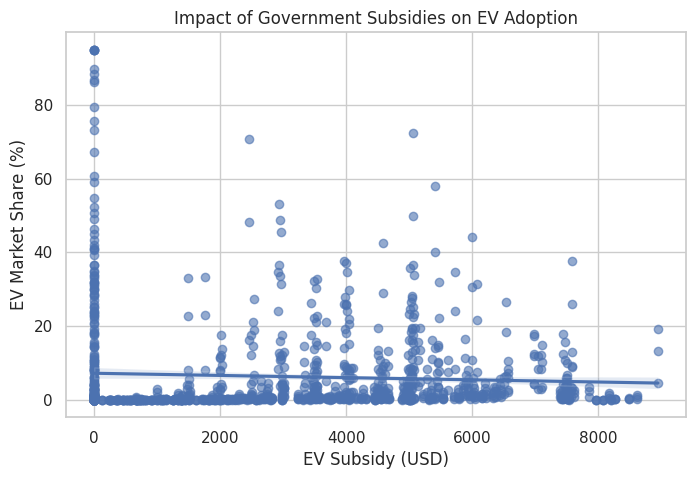

In [13]:
plt.figure(figsize=(8,5))

sns.regplot(
    x='ev_subsidy_usd',
    y='ev_market_share',
    data=df,
    scatter_kws={'alpha':0.6}
)

plt.xlabel("EV Subsidy (USD)")
plt.ylabel("EV Market Share (%)")
plt.title("Impact of Government Subsidies on EV Adoption")

plt.show()

# H4: GDP vs EV Market Share

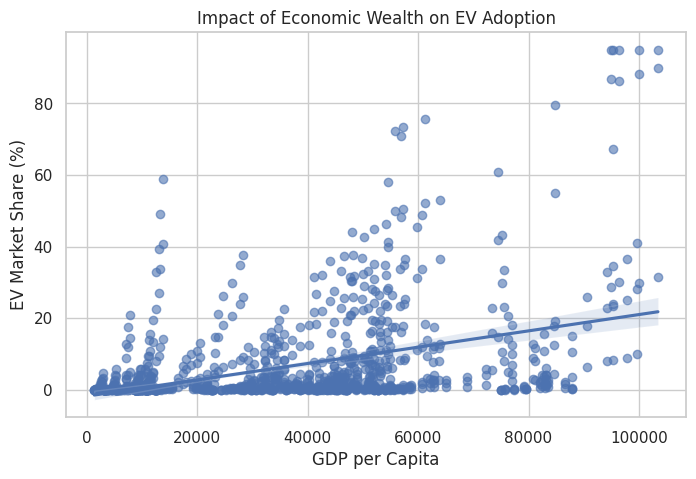

In [17]:
plt.figure(figsize=(8,5))

sns.regplot(
    x='gdp_per_capita',
    y='ev_market_share',
    data=df,
    scatter_kws={'alpha':0.6}
)

plt.xlabel("GDP per Capita")
plt.ylabel("EV Market Share (%)")
plt.title("Impact of Economic Wealth on EV Adoption")

plt.show()